In [711]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as mp 
import seaborn as s
import tensorflow as tf

Load dataset

In [712]:
df=pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

View Dataset

In [713]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [714]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [715]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
755,6683-VLCTZ,Male,1,No,No,20,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.55,1842.8,Yes
6209,3417-TSCIC,Male,0,No,No,29,No,No phone service,DSL,No,...,No,No,No,No,One year,Yes,Mailed check,24.85,788.05,No
5563,4397-FRLTA,Female,0,No,No,4,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,84.5,No
4358,6253-WRFHY,Male,0,Yes,Yes,13,Yes,No,DSL,No,...,No,No,Yes,Yes,One year,Yes,Electronic check,64.75,877.35,No
5987,1099-GODLO,Female,0,Yes,Yes,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.35,20.35,No


In [716]:
df.shape

(7043, 21)

In [717]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Data type

In [718]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Change DataType

In [719]:
df['TotalCharges']=df['TotalCharges'].str.strip()
df['TotalCharges']=pd.to_numeric(df['TotalCharges'])

Statics

In [720]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Null Values

In [721]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Heandle null values

In [722]:
df["TotalCharges"]=df["TotalCharges"].fillna(
    df["TotalCharges"].mean()
)

Duplicate Values

In [723]:
df.duplicated().sum()

np.int64(0)

Outliers

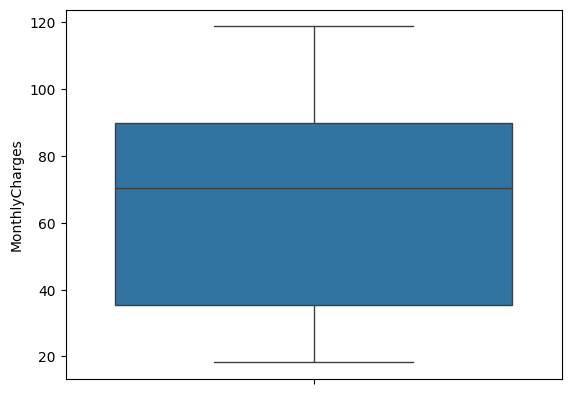

In [724]:
s.boxplot(df['MonthlyCharges'])
mp.show()

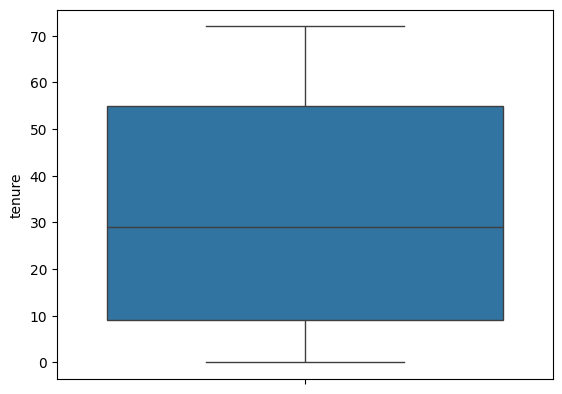

In [725]:
s.boxplot(df['tenure'])
mp.show()

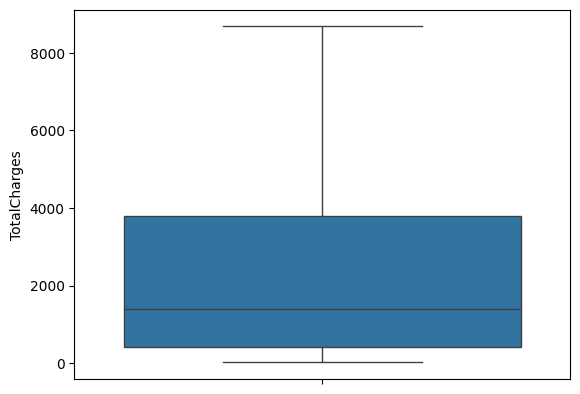

In [726]:
s.boxplot(df['TotalCharges'])
mp.show()

Encoding

In [727]:
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [728]:
gender_encoder=sk.preprocessing.OneHotEncoder()
en_result=gender_encoder.fit_transform(df[['gender']])
df['gender']=en_result.toarray()[:,0]

In [729]:
df['Partner'].unique()

array(['Yes', 'No'], dtype=object)

In [730]:
partner_encoder=sk.preprocessing.OneHotEncoder()
en_result=partner_encoder.fit_transform(df[['Partner']])
df['Partner']=en_result.toarray()[:,0]

In [731]:
df['Dependents'].unique()

array(['No', 'Yes'], dtype=object)

In [732]:
dependent_encoder=sk.preprocessing.OneHotEncoder()
en_result=dependent_encoder.fit_transform(df[['Dependents']])
df['Dependents']=en_result.toarray()[:,0]

In [733]:
df['PhoneService'].unique()

array(['No', 'Yes'], dtype=object)

In [734]:
PhoneService_encoder=sk.preprocessing.OneHotEncoder()
en_result=PhoneService_encoder.fit_transform(df[['PhoneService']])
df['PhoneService']=en_result.toarray()[:,0]

In [735]:
df['MultipleLines'].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [736]:
MultipleLines_encoder=sk.preprocessing.LabelEncoder()
df['MultipleLines']=MultipleLines_encoder.fit_transform(df['MultipleLines'])

In [737]:
df['InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [738]:
InternetService_encoder=sk.preprocessing.LabelEncoder()
df['InternetService']=InternetService_encoder.fit_transform(df['InternetService'])

In [739]:
df['OnlineSecurity'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [740]:
OnlineSecurity_encoder=sk.preprocessing.LabelEncoder()
df['OnlineSecurity']=OnlineSecurity_encoder.fit_transform(df['OnlineSecurity'])

In [741]:
df['OnlineBackup'].unique()

array(['Yes', 'No', 'No internet service'], dtype=object)

In [742]:
OnlineBackup_encoder=sk.preprocessing.LabelEncoder()
df['OnlineBackup']=OnlineBackup_encoder.fit_transform(df['OnlineBackup'])

In [743]:
df['DeviceProtection'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [744]:
DeviceProtection_encoder=sk.preprocessing.LabelEncoder()
df['DeviceProtection']=DeviceProtection_encoder.fit_transform(df['DeviceProtection'])

In [745]:
df['TechSupport'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [746]:
TechSupport_encoder=sk.preprocessing.LabelEncoder()
df['TechSupport']=TechSupport_encoder.fit_transform(df['TechSupport'])

In [747]:
df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [748]:
PaymentMethod_encoder=sk.preprocessing.LabelEncoder()
df['PaymentMethod']=PaymentMethod_encoder.fit_transform(df['PaymentMethod'])

In [749]:
df['StreamingMovies'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [750]:
StremingMovies_encoder=sk.preprocessing.LabelEncoder()
df['StreamingMovies']=StremingMovies_encoder.fit_transform(df['StreamingMovies'])

In [751]:
df['StreamingTV'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [752]:
StremingTV_encoder=sk.preprocessing.LabelEncoder()
df['StreamingTV']=StremingTV_encoder.fit_transform(df['StreamingTV'])

In [753]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [754]:
Contract_encoder=sk.preprocessing.LabelEncoder()
df['Contract']=Contract_encoder.fit_transform(df['Contract'])

In [755]:
df['PaperlessBilling'].unique()

array(['Yes', 'No'], dtype=object)

In [756]:
PaperlessBilling_encoder=sk.preprocessing.OneHotEncoder()
en_result=PaperlessBilling_encoder.fit_transform(df[['PaperlessBilling']])
df['PaperlessBilling']=en_result.toarray()[:,0]

In [757]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [758]:
Churn_encoder=sk.preprocessing.OneHotEncoder()
en_result=Churn_encoder.fit_transform(df[['Churn']])
df['Churn']=en_result.toarray()[:,0]

In [759]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   float64
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   float64
 4   Dependents        7043 non-null   float64
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   float64
 7   MultipleLines     7043 non-null   int64  
 8   InternetService   7043 non-null   int64  
 9   OnlineSecurity    7043 non-null   int64  
 10  OnlineBackup      7043 non-null   int64  
 11  DeviceProtection  7043 non-null   int64  
 12  TechSupport       7043 non-null   int64  
 13  StreamingTV       7043 non-null   int64  
 14  StreamingMovies   7043 non-null   int64  
 15  Contract          7043 non-null   int64  
 16  PaperlessBilling  7043 non-null   float64


In [760]:
df.sample(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3988,6194-HBGQN,0.0,0,1.0,1.0,51,0.0,2,0,2,...,2,2,2,0,1,0.0,1,81.15,4126.20,1.0
3884,4521-YEEHE,1.0,0,0.0,1.0,18,0.0,2,1,0,...,0,2,2,0,0,0.0,2,88.85,1594.75,1.0
3172,8393-DLHGA,0.0,0,1.0,0.0,25,0.0,0,1,0,...,0,0,2,2,0,0.0,2,95.90,2448.75,0.0


Feature Scalling

In [761]:
df['tenure']=sk.preprocessing.minmax_scale(df['tenure'])

In [762]:
df['MonthlyCharges']=sk.preprocessing.minmax_scale(df['MonthlyCharges'])

In [763]:
df['TotalCharges']=sk.preprocessing.minmax_scale(df['TotalCharges'])

corelation

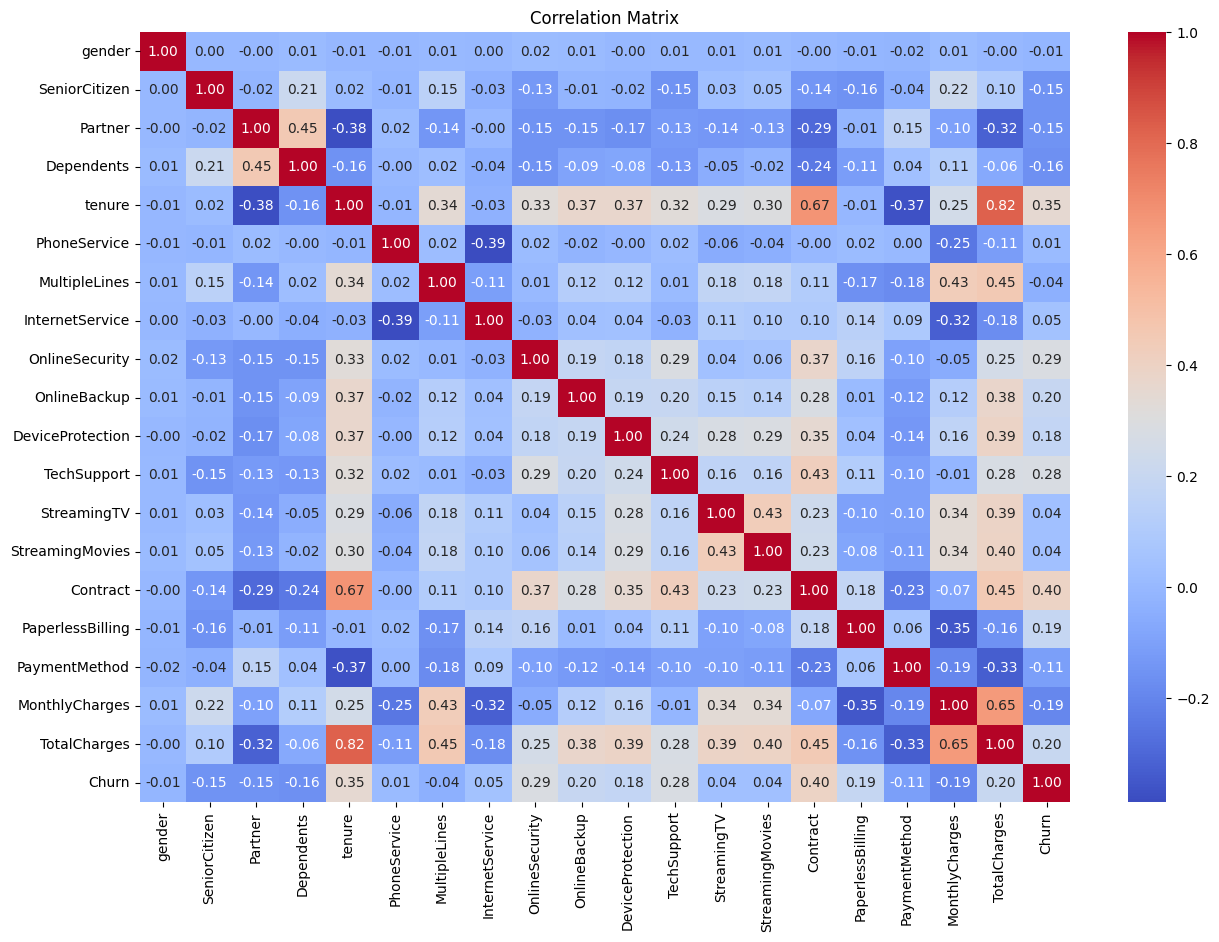

In [764]:
mp.figure(figsize=(15,10))

s.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

mp.title("Correlation Matrix")

mp.show()

Divid input and output features

In [765]:
y=df['Churn']
x=df.drop(columns=['customerID','Churn'])

divid train and test data

In [766]:
x_train,x_test,y_train,y_test=sk.model_selection.train_test_split(x,y,test_size=0.2)

ANN

In [767]:
model=tf.keras.Sequential([
      tf.keras.layers.Dense(64,activation='relu'),
      tf.keras.layers.Dense(32,activation='relu'),
      tf.keras.layers.Dense(1,activation='sigmoid')
])
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [768]:
es=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)
mc=tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [769]:
model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[es,mc]
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7502 - loss: 0.4876 - val_accuracy: 0.7888 - val_loss: 0.4282
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7879 - loss: 0.4435 - val_accuracy: 0.7888 - val_loss: 0.4222
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7954 - loss: 0.4345 - val_accuracy: 0.7950 - val_loss: 0.4218
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8014 - loss: 0.4270 - val_accuracy: 0.7853 - val_loss: 0.4213
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7992 - loss: 0.4209 - val_accuracy: 0.7835 - val_loss: 0.4260
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8054 - loss: 0.4188 - val_accuracy: 0.7888 - val_loss: 0.4241
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8061 - loss: 0.4141 - val_accuracy: 0.7826 - val_loss: 0.4377
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8063 - loss: 0.4124 - val_accu

In [770]:
loss,accuracy=model.evaluate(
                x_test,
                y_test
                )

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8034 - loss: 0.4199 


In [771]:
print("loss = ",loss)
print("accuracy = ",accuracy)

loss =  0.4198705554008484
accuracy =  0.8034066557884216
